## **Lab 8: Privacy Preserving In Deep Learning**
In this lab, we will train a deep learning model using Pytorch. We will also explore how differential privacy works
in stochastic gradient descent (DP-SGD). After this lab, we expect students to know:

# **Objectives**
1. PyTorch: What is PyTorch; How to install PyTorch;
2. Tensor: What is tensor; How to create tensor; How to use tensor;
3. MNIST: What is MNIST dataset; How does the dataset look like;
4. Deep Learning: How to build a neural network; How to train a model;
5. DP-SGD: How does DP-SGD work in deep learning; How does differential privacy affect model
performance



# 1.3. Testing task: Build your first tensor

A tensor is a generic multiple-dimensional array, very similar to numpy arrays, or matrix. Tensors are used for
arbitrary numeric computation. Now, let's build your first tensor. Create a new python file in Jupyter notebook,
and type the following code:

In [ ]:
import torch, torchvision

x = torch.tensor([1,1,1,1,1])
y = torch.tensor([[1,1,1,1,1], [1,1,1,1,1]])
print("tensor x is:", x)
print("tensor y is:", y)

tensor x is: tensor([1, 1, 1, 1, 1])
tensor y is: tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]])


A tensor has a shape, to describe the number of dimensions and the length of each demension of this tensor.
We can get the tensor's shape by:

In [ ]:
print("tensor x's shape is:", x.shape)
print("tensor y's shape is:", y.shape)

tensor x's shape is: torch.Size([5])
tensor y's shape is: torch.Size([2, 5])


Tensors with the same shape can work with basic operations, e.g.

In [ ]:
z = x + x
a = x * 2
b = x / x
print("New tensor z is:", z)
print("New tensor a is:", a)
print("New tensor a is:", b)
print(a==z)

New tensor z is: tensor([2, 2, 2, 2, 2])
New tensor a is: tensor([2, 2, 2, 2, 2])
New tensor a is: tensor([1., 1., 1., 1., 1.])
tensor([True, True, True, True, True])


# **Practice: Basic arithmetic of tensors**

In this practice, students are required to create tensors and operate basic arithmetic of tensors. We have the
following tasks:
1. Create two tensors "a" and "b". tensor "a" is (2,4,6,8,10), and tensor "b" is (2,2,2,2,2).
2. Create a new tensor "c" which is equal to the sum of tensors "a" and "b". (c = a + b)
3. Create a new tensor "d" which is equal to the difference of tensors "a" and "b". (d = a - b)
4. Create a new tensor "e" which is equal to the product of tensors "a" and "b". (e = a * b)
5. Create a new tensor "f" which is equal to the division of tensors "a" and "b". (f = a / b)

# 2. **Build a neural network**
2.1. **MNIST Dataset**

The MNIST database (Modified National Institute of Standards and Technology database) is a large database of
handwritten digits that is commonly used for training various image processing systems. The MNIST database
contains 60,000 training images and 10,000 testing images. Training images are used to training and
optimizing the model, and test images are used to test the model performance.
We import and download MNIST dataset from torchvision.

In [ ]:
import torch
from torch import nn
from torchvision.datasets import MNIST
import numpy as np
from torch.autograd import Variable
import matplotlib.pyplot as plt
# Download the training dataset
train_set = MNIST('./data', train=True, download=True)
# Download the test dataset
test_set = MNIST('./data', train=False, download=True)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 52174358.19it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 2335776.28it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 12520895.15it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 4255199.64it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Now, let's see how the image looks like. We select any number of training images, e.g. 7th (a digital number 3).
We print its label and the result shows as "3". We can see a real written number "3" in the image.

In [ ]:
# Show the first image of the dataset
a_data, a_label = train_set[7]
print(a_data)
print(a_label)
a_data.show() # x is a PIL.Image here

<PIL.Image.Image image mode=L size=28x28 at 0x7F959015B0D0>
3


Now, we transform this image and store its pixel as a numpy array. We then print it using plot.

[[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  38.  43. 105.
  255. 253. 253. 253. 253. 253. 174.   6.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.  43. 139. 224. 226. 252.
  253. 252. 252. 252. 252. 252. 252. 158.  14.   0.   0.  

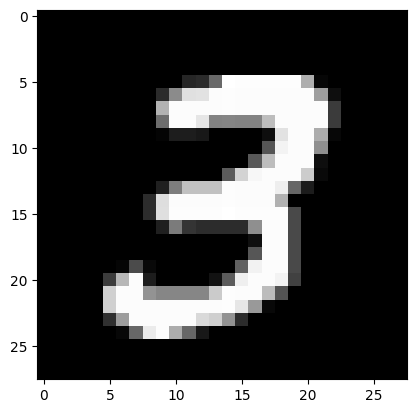

In [ ]:
# Print the Image in jupyter with numpy
a_data = np.array(a_data, dtype = 'float32')
print(a_data)
plt.imshow(a_data, cmap = 'gray')

Now, we transform all images and store their pixel in numpy arrary for training inputs. All images's pixel is 28 *
28 = 784, so we need to reshape them as a one-dimension vector used for the inputs of the neural network.

torch.Size([1, 28, 28])
3


In [ ]:
def get_data(x):
  x = np.array(x, dtype='float32') / 255
  x = (x - 0.5) / 0.5
  x = x.reshape((-1,))
  x = torch.from_numpy(x)
  return x
train_set = MNIST('./data', train = True, transform = get_data, download = True)
test_set = MNIST('./data', train = False, transform = get_data, download = True)
a, a_label = train_set[7]
print(a.shape)
print(a_label)

torch.Size([784])
3


##**2.2 Set the batch size**
We Use DataLoader to define a data iterator. It's very important to create this iterator because the network
cannot read a large amount of data once. We need the iterator to divide all images into many batches with a
defined batch size. In our case, we set training data's batch size as 64, and test data's batch size as 128.

In [ ]:
from torch.utils.data import DataLoader
train_data = DataLoader(train_set, batch_size = 64, shuffle = True)
test_data = DataLoader(test_set, batch_size = 128, shuffle = False)
a, a_label = next(iter(train_data))
# Print a batch of data
print(a.shape)
print(a_label.shape)

torch.Size([64, 784])
torch.Size([64])


torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
train_data.dataset.data


tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

# **2.3 Build the first network and train model**


Now, we start building our first network. we use Sequential to define a neural network with four layers. We use linear style in our model. In each layer, the first number is the size of inputs, and the second number is the size of outputs. Please note that the next layer's inputs' size must be equal to the outputs' size of the previous layer.

In [ ]:
net = nn.Sequential(
# First layer, input size 784, output size 400
nn.Linear(784, 400),
nn.ReLU(),
# Second layer, input size 400, output size 200
nn.Linear(400, 200),
nn.ReLU(),
# Third layer, input size 200, output size 100
nn.Linear(200, 100),
nn.ReLU(),
# Fourth layer, input size 100, output size 10
nn.Linear(100, 10)
)

After building a network, we need to set the loss function and optimizer. In this case, we use Cross Entropy Loss function as our loss function, and SGD as our optimizer. The definition of them is shown below.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), 1e-1)

In [ ]:
# Build lists to store training loss,
# training accuracy, test loss and test accuracy
losses = []
acces = []
eval_losses = []
eval_acces = []

Now, we can start training. We need to set the number of training epochs. Deep learning model contains too much computation which may require a long time each epoch. In our case, each epoch may spend approximate 5 seconds.
We need an appropriate epoch number because a small epoch number may cause that the model has not reached the convergence. A big epoch number may waste computation resources and time because the model has already reached the convergence and the performance cannot get better using the same model and
training data

In [ ]:
# We set training epochs here.
epochs = 20

In [ ]:
for e in range(epochs):
  # Training
  train_loss = 0
  train_acc = 0
  net.train()
  for im, label in train_data:
    im = Variable(im)
    label = Variable(label)
    out = net(im)
    loss = criterion(out, label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    _, pred = out.max(1)
    num_correct = (pred==label).sum().item()
    acc = num_correct / im.shape[0]
    train_acc += acc
  losses.append(train_loss / len(train_data))
  acces.append(train_acc / len(train_data))

  # Testing
  eval_loss = 0
  eval_acc = 0
  net.eval()
  for im, label in test_data:
    im = Variable(im)
    label = Variable(label)
    out = net(im)
    loss = criterion(out, label)
    # Save loss
    eval_loss += loss.item()
    # Save accuracy
    _, pred = out. max(1)
    num_correct = (pred==label).sum().item()
    acc = num_correct / im.shape[0]
    eval_acc += acc
  eval_losses.append(eval_loss / len(test_data))
  eval_acces.append(eval_acc / len(test_data))
  print('epoch:{}, Train Loss:{:.4f}, Train Acc:{:.4f}, Eval Loss:{:.4f}, Eval Acc:{:.4f}'.format(
      e,
      train_loss/len(train_data),
      train_acc/len(train_data),
      eval_loss / len(test_data),  # Assuming you want the average eval_loss
      eval_acc / len(test_data)    # Assuming you want the average eval_acc
  ))

epoch:0, Train Loss:0.0138, Train Acc:0.9965, Eval Loss:0.0838, Eval Acc:0.9763
epoch:1, Train Loss:0.0154, Train Acc:0.9954, Eval Loss:0.0767, Eval Acc:0.9796
epoch:2, Train Loss:0.0093, Train Acc:0.9970, Eval Loss:0.0775, Eval Acc:0.9812
epoch:3, Train Loss:0.0074, Train Acc:0.9977, Eval Loss:0.0687, Eval Acc:0.9838
epoch:4, Train Loss:0.0042, Train Acc:0.9987, Eval Loss:0.0722, Eval Acc:0.9827
epoch:5, Train Loss:0.0038, Train Acc:0.9990, Eval Loss:0.0729, Eval Acc:0.9841
epoch:6, Train Loss:0.0026, Train Acc:0.9994, Eval Loss:0.0755, Eval Acc:0.9831
epoch:7, Train Loss:0.0046, Train Acc:0.9986, Eval Loss:0.0757, Eval Acc:0.9841
epoch:8, Train Loss:0.0065, Train Acc:0.9982, Eval Loss:0.0725, Eval Acc:0.9838
epoch:9, Train Loss:0.0015, Train Acc:0.9996, Eval Loss:0.0758, Eval Acc:0.9843
epoch:10, Train Loss:0.0005, Train Acc:1.0000, Eval Loss:0.0740, Eval Acc:0.9851
epoch:11, Train Loss:0.0005, Train Acc:0.9999, Eval Loss:0.0739, Eval Acc:0.9857
epoch:12, Train Loss:0.0004, Train Acc

Now, we plot the training loss, training accuracy, test loss and test accuracy in axis

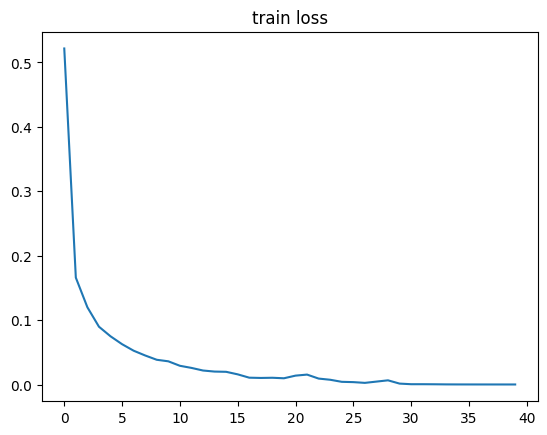

In [ ]:
# Print training loss
plt.title('train loss')
plt.plot(np.arange(len(losses)), losses)
plt.show()


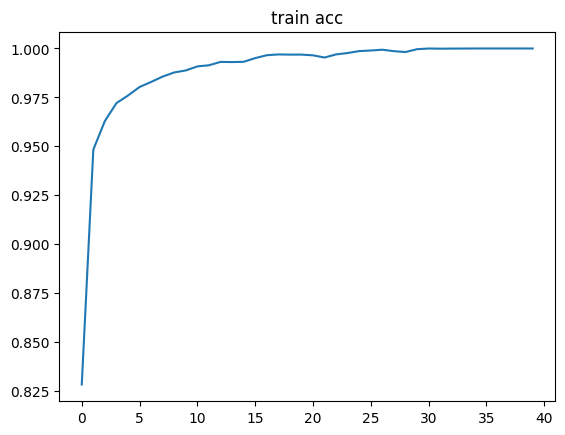

In [ ]:
# Print training accuracy
plt.plot(np.arange(len(acces)), acces)
plt.title('train acc')
plt.show()

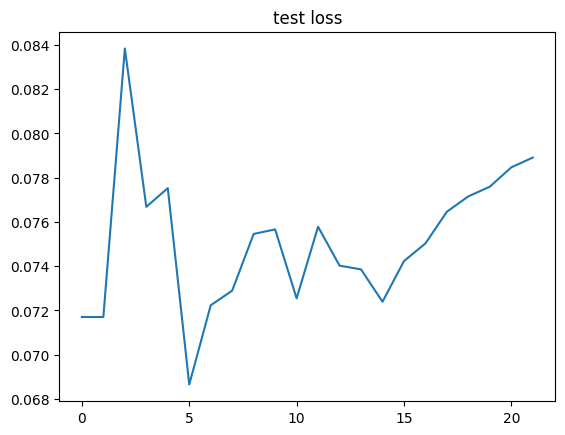

In [ ]:
# Print test loss
plt.plot(np.arange(len(eval_losses)), eval_losses)
plt.title('test loss')
plt.show()

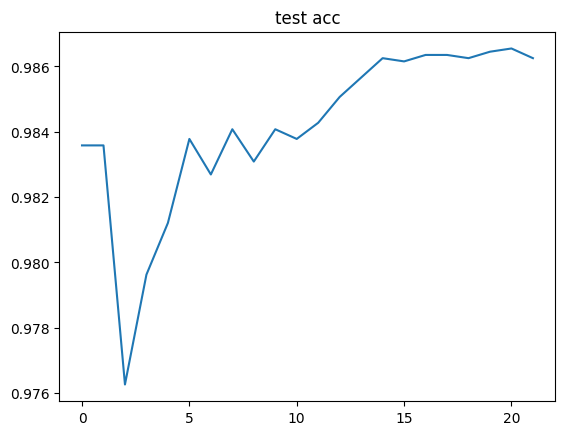

In [ ]:
# Print test accuracy
plt.plot(np.arange(len(eval_acces)), eval_acces)
plt.title('test acc')
plt.show()

Now, we will explore the impact of differential privacy on the model's performance. DPSGD combines differential privacy mechanism and SGD together as an optimizer. We will use DPSGD instead of SGD. Please make sure you have download DPSGD.py file with the same root of this file

In [ ]:
import math
import torch

import uuid
import torch
from torch.optim.optimizer import Optimizer, required

import torch.nn.functional as F
PI = torch.FloatTensor([math.pi])
NORM = (torch.sqrt(2.0 * PI))
def norm_pdf(x,mean,std):
    y = (x-mean)/std
    return (torch.exp( -(y).pow(2) / 2.0) / NORM) / std


class DPSGD(Optimizer):


    def __init__(self, params, lr = required, momentum = 0, dampening = 0,
                 weight_decay = 0, nesterov = False,C = 1,noise_multiplier = 1.0,batch_size = 256):
        if lr is not required and lr < 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if momentum < 0.0:
            raise ValueError("Invalid momentum value: {}".format(momentum))
        if weight_decay < 0.0:
            raise ValueError("Invalid weight_decay value: {}".format(weight_decay))

        defaults = dict(lr = lr, momentum=momentum, dampening=dampening,
                        weight_decay=weight_decay, nesterov=nesterov)
        if nesterov and (momentum <= 0 or dampening != 0):
            raise ValueError("Nesterov momentum requires a momentum and zero dampening")
        super(DPSGD, self).__init__(params, defaults)


        self.batch_size = batch_size

        self.C = C
        self.bigger_batch = {}


        self.bigger_batch_count = {}
        self.noise_multiplier = noise_multiplier

    def __setstate__(self, state):
        super(SGD, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('nesterov', False)

    def step(self, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        noise_std =self.noise_multiplier *self.C

        loss = None
        if closure is not None:
            loss = closure()


        norm  = 0


        for group in self.param_groups:

            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data


                if not hasattr(p,'myid'):
                    p.myid = uuid.uuid4()
                    self.bigger_batch[p.myid] = torch.zeros_like(grad)

                    self.bigger_batch_count[p.myid] =  torch.LongTensor(size=[1]).zero_()

                norm+=grad.norm()**2.0
        norm=norm**(0.5)


        for group in self.param_groups:

            for p in group['params']:
                grad = p.grad.data


                cliped = (grad*self.C) /( torch.max(norm,torch.ones_like(norm)*self.C))
                self.bigger_batch [p.myid].add_(cliped)
                self.bigger_batch_count[p.myid]+=1


        if   self.bigger_batch_count[p.myid] == self.batch_size:


            for group in self.param_groups:

                for p in group['params']:




                    base =  self.bigger_batch[p.myid]
                    my_rand = torch.zeros_like(base)
                    my_rand.normal_(mean=0, std =noise_std  )

                    base.add_(my_rand)

                    base = base/float(self.batch_size)

                    self.bigger_batch[p.myid] =base









            for group in self.param_groups:
                weight_decay = group['weight_decay']
                momentum = group['momentum']
                dampening = group['dampening']
                nesterov = group['nesterov']

                for p in group['params']:
                    if p.grad is None:
                        continue
                    d_p = self.bigger_batch[p.myid]
                    if weight_decay != 0:
                        d_p.add_(weight_decay, p.data)
                    if momentum != 0:
                        param_state = self.state[p]
                        if 'momentum_buffer' not in param_state:
                            buf = param_state['momentum_buffer'] = torch.clone(d_p).detach()
                        else:
                            buf = param_state['momentum_buffer']
                            buf.mul_(momentum).add_(1 - dampening, d_p)
                        if nesterov:
                            d_p = d_p.add(momentum, buf)
                        else:
                            d_p = buf

                    p.data.add_(-group['lr'], d_p)
                    self.bigger_batch[p.myid].zero_()
                    self.bigger_batch_count[p.myid].zero_()

        return loss


In [ ]:
# Build a new network named "net1".
# The name of this net must be different with the last one.
net1 = nn.Sequential(
# First layer, input size 784, output size 400
nn.Linear(784, 400),
nn.ReLU(),
# Second layer, input size 400, output size 200
nn.Linear(400, 200),
nn.ReLU(),
# Third layer, input size 200, output size 100
nn.Linear(200, 100),
nn.ReLU(),
# Fourth layer, input size 100, output size 10
nn.Linear(100, 10)
)
# Define loss function
# import DPSGD
criterion = nn.CrossEntropyLoss()
# Define optimizer. We use DPSGD here, which conbines differential privacy mecha
optimizer = DPSGD(net1.parameters(),lr=1e-1,batch_size=32,C=1.0,noise_multiplier=1.0)

In [ ]:
# Start training
losses1 = []
acces1 = []
eval_losses1 = []
eval_acces1 = []
epochs = 20
for e in range(epochs):
  train_loss = 0
  train_acc = 0
  net1.train()
  for im, label in train_data:
    im = Variable(im)
    label = Variable(label)
    # Forward
    out = net1(im)
    loss = criterion(out, label)
    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Training loss calculation
    train_loss += loss.item()
    #
    _, pred = out.max(1)
    num_correct = (pred == label).sum().item()
    acc = num_correct / im.shape[0]
    train_acc += acc
  losses1.append(train_loss / len(train_data))
  acces1.append(train_acc / len(train_data))
  # Test
  eval_loss = 0
  eval_acc = 0
  net.eval()
  for im, label in test_data:
    im = Variable(im)
    label = Variable(label)
    out = net1(im)
    loss = criterion(out, label)
    # Test loss calculation
    eval_loss += loss.item()
    # Test accuracy
    _, pred = out. max(1)
    num_correct = (pred==label).sum().item()
    acc = num_correct / im.shape[0]
    eval_acc += acc
  eval_losses1.append(eval_loss / len(test_data))
  eval_acces1.append(eval_acc / len(test_data))
  print('epoch:{}, Train Loss:{:.4f}, Train Acc:{:.4f}, Eval Loss:{:.4f}, Eval Acc:{:.4f}'.format(
      e,
      train_loss/len(train_data),
      train_acc/len(train_data),
      eval_loss / len(test_data),  # Assuming you want the average eval_loss
      eval_acc / len(test_data)    # Assuming you want the average eval_acc
  ))

<ipython-input-40-54499eb1be51>:146: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:1581.)
  p.data.add_(-group['lr'], d_p)


epoch:0, Train Loss:2.1518, Train Acc:0.4559, Eval Loss:1.8104, Eval Acc:0.6299
epoch:1, Train Loss:1.3784, Train Acc:0.6950, Eval Loss:1.0287, Eval Acc:0.7545
epoch:2, Train Loss:0.9059, Train Acc:0.7589, Eval Loss:0.7908, Eval Acc:0.7680
epoch:3, Train Loss:0.7395, Train Acc:0.7784, Eval Loss:0.6522, Eval Acc:0.8134
epoch:4, Train Loss:0.6437, Train Acc:0.8056, Eval Loss:0.6001, Eval Acc:0.8102
epoch:5, Train Loss:0.5825, Train Acc:0.8194, Eval Loss:0.5224, Eval Acc:0.8405
epoch:6, Train Loss:0.5372, Train Acc:0.8295, Eval Loss:0.4671, Eval Acc:0.8554
epoch:7, Train Loss:0.5059, Train Acc:0.8407, Eval Loss:0.4799, Eval Acc:0.8499
epoch:8, Train Loss:0.4915, Train Acc:0.8467, Eval Loss:0.4781, Eval Acc:0.8563
epoch:9, Train Loss:0.4706, Train Acc:0.8540, Eval Loss:0.4279, Eval Acc:0.8730
epoch:10, Train Loss:0.4416, Train Acc:0.8630, Eval Loss:0.4102, Eval Acc:0.8703
epoch:11, Train Loss:0.4255, Train Acc:0.8693, Eval Loss:0.3958, Eval Acc:0.8800
epoch:12, Train Loss:0.4185, Train Acc

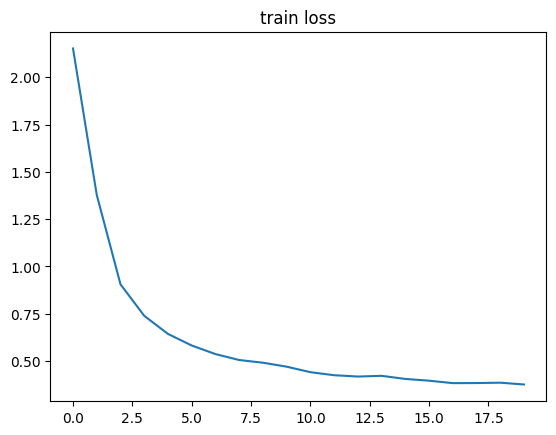

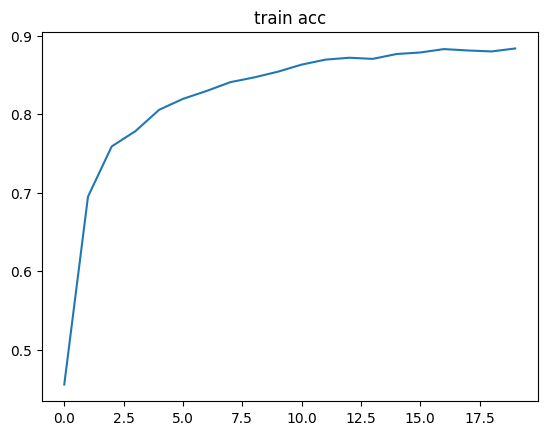

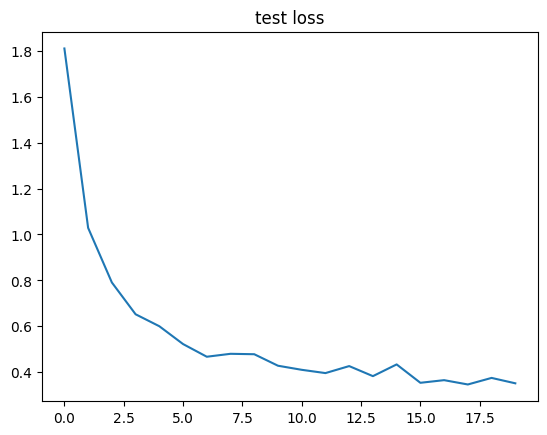

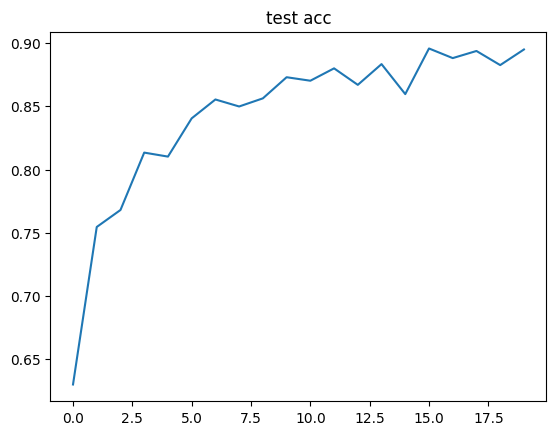

In [ ]:
# Print training loss
plt.title('train loss')
plt.plot(np.arange(len(losses1)), losses1)
plt.show()
# Print training accuracy
plt.plot(np.arange(len(acces1)), acces1)
plt.title('train acc')
plt.show()
# Print test loss
plt.plot(np.arange(len(eval_losses1)), eval_losses1)
plt.title('test loss')
plt.show()
# Print test accuracy
plt.plot(np.arange(len(eval_acces1)), eval_acces1)
plt.title('test acc')
plt.show()

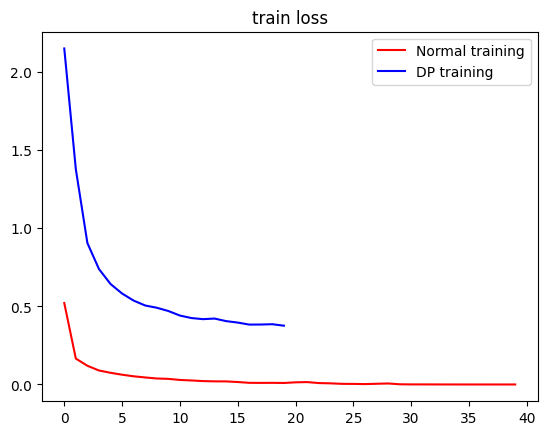

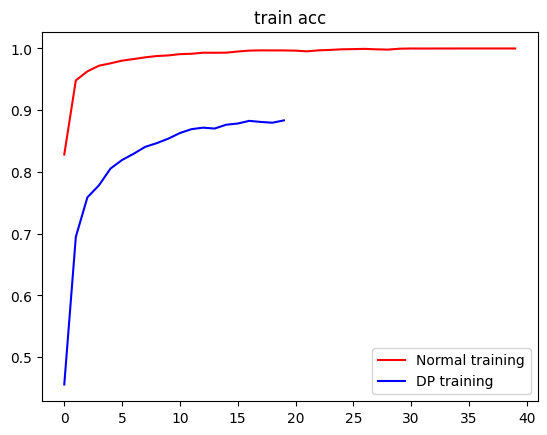

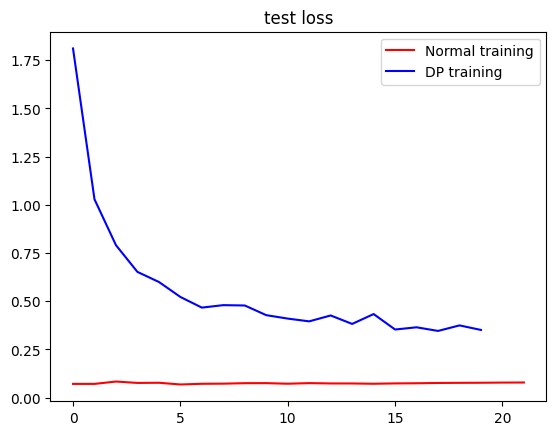

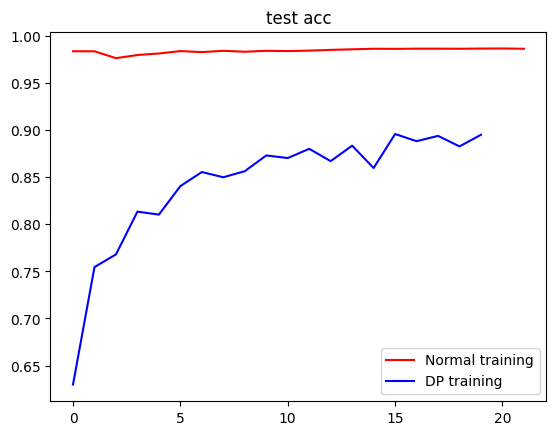

In [ ]:
# Assuming losses and losses1 are already defined

# Print training loss
plt.title('train loss')
plt.plot(np.arange(len(losses)), [losses[i] for i in range(len(losses))], color='red', label='Normal training')
plt.plot(np.arange(len(losses1)), [losses1[i] for i in range(len(losses1))], color='blue', label='DP training')
plt.legend()
plt.show()

# Assuming acces and acces1 are already defined

# Print training accuracy
plt.title('train acc')
plt.plot(np.arange(len(acces)), [acces[i] for i in range(len(acces))], color='red', label='Normal training')
plt.plot(np.arange(len(acces1)), [acces1[i] for i in range(len(acces1))], color='blue', label='DP training')
plt.legend()
plt.show()

# Assuming eval_losses and eval_losses1 are already defined

# Print test loss
plt.title('test loss')
plt.plot(np.arange(len(eval_losses)), [eval_losses[i] for i in range(len(eval_losses))], color='red', label='Normal training')
plt.plot(np.arange(len(eval_losses1)), [eval_losses1[i] for i in range(len(eval_losses1))], color='blue', label='DP training')
plt.legend()
plt.show()

# Assuming eval_acces and eval_acces1 are already defined

# Print test accuracy
plt.title('test acc')
plt.plot(np.arange(len(eval_acces)), [eval_acces[i] for i in range(len(eval_acces))], color='red', label='Normal training')
plt.plot(np.arange(len(eval_acces1)), [eval_acces1[i] for i in range(len(eval_acces1))], color='blue', label='DP training')
plt.legend()
plt.show()

# **Conclusion**
In this lab, we have learnt:
1. defining tensors;
2. basic operations of tensors;
3. MNIST dataset
4. deep leaning and neural network;
5. DP-SGD in deep learning
From the training results we can know that:
1. the noise from differential privacy (DP-SGD) may slightly reduce the accuracy of model.
2. the size of noise is affected by sensitivity and privacy budget.
3. it is important to balance the privacy and model ultility.

Another Version write by Luoyu

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) #zero-centering data distribution
])

train_set = MNIST('./data', train = True, transform = transform, download = True)
test_set = MNIST('./data', train = False, transform = transform, download = True)
a, a_label = train_set[7]
print(a.shape)
print(a_label)

from torch.utils.data import DataLoader
train_data = DataLoader(train_set, batch_size = 64, shuffle = True)
test_data = DataLoader(test_set, batch_size = 128, shuffle = False)
a, a_label = next(iter(train_data))
# Print a batch of data
print(a.shape)
print(a_label.shape)

torch.Size([1, 28, 28])
3
torch.Size([64, 1, 28, 28])
torch.Size([64])


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


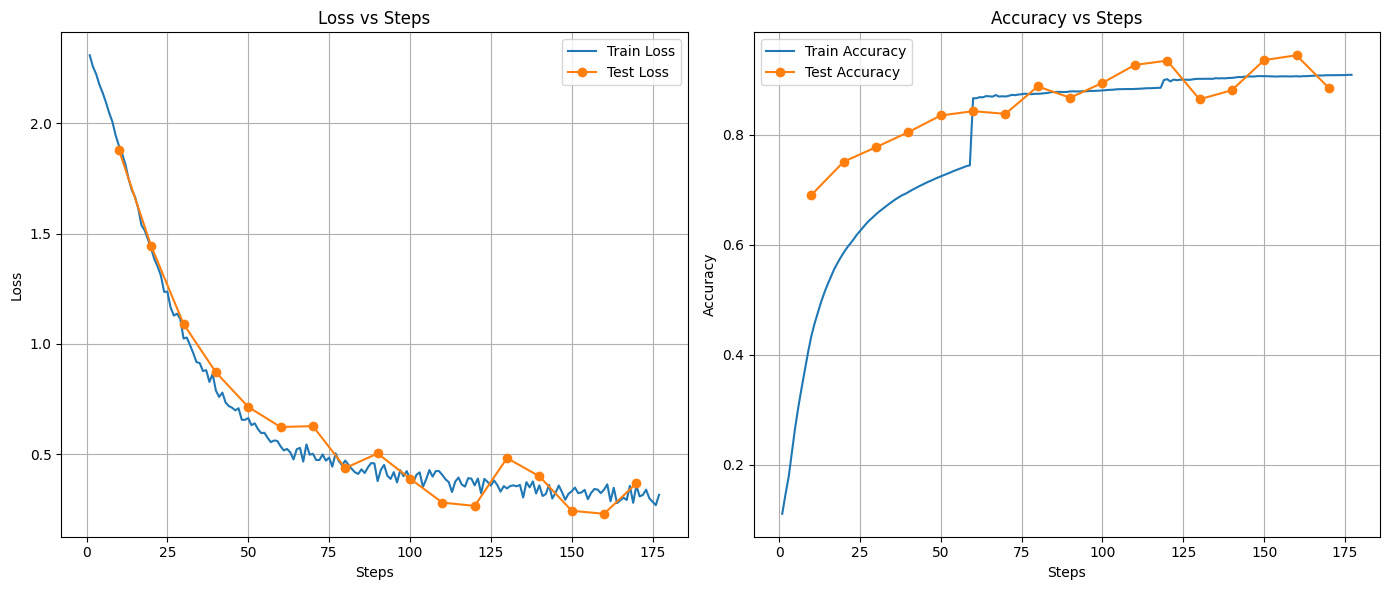

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# define eval
def evaluate_on_random_batch(model, device, test_loader, criterion):
    model.eval()
    with torch.no_grad():
        # sampling a batch
        test_batches = list(test_loader)
        data, target = random.choice(test_batches)
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target).item()
        preds = output.argmax(dim=1)
        correct = preds.eq(target).sum().item()
        accuracy = correct / target.size(0)
    model.train()
    return loss, accuracy

# define model
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        x = x.view(-1, 28*28)  # flatten dim
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def main():
    # check device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    transform = transforms.Compose([transforms.ToTensor()])

    # load data
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    batch_size = 1024
    num_workers = 4
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    #init model, loss and optimizer
    model = SimpleNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # params
    num_epochs = 3
    eval_steps = 10

    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []
    train_steps = []
    test_steps = []

    global_step = 0

    for epoch in range(num_epochs):
        model.train()
        total_correct = 0
        total_samples = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for batch_idx, (data, target) in enumerate(progress_bar):
            global_step += 1
            data, target = data.to(device), target.to(device)

            # forward pass
            output = model(data)
            loss = criterion(output, target)

            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # calculate acc
            preds = output.argmax(dim=1)
            correct = preds.eq(target).sum().item()
            total_correct += correct
            total_samples += target.size(0)
            accuracy = total_correct / total_samples

            train_losses.append(loss.item())
            train_accuracies.append(accuracy)
            train_steps.append(global_step)

            # update progress bar
            progress_bar.set_postfix(loss=loss.item(), accuracy=accuracy)

            # every eval_steps ，test on test set
            if global_step % eval_steps == 0:
                test_loss, test_accuracy = evaluate_on_random_batch(model, device, test_loader, criterion)
                test_losses.append(test_loss)
                test_accuracies.append(test_accuracy)
                test_steps.append(global_step)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

    # plot loss
    ax1.plot(train_steps, train_losses, label='Train Loss')
    ax1.plot(test_steps, test_losses, label='Test Loss', marker='o')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss vs Steps')
    ax1.legend()
    ax1.grid(True)

    # plot acc
    ax2.plot(train_steps, train_accuracies, label='Train Accuracy')
    ax2.plot(test_steps, test_accuracies, label='Test Accuracy', marker='o')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy vs Steps')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.9/239.9 kB 5.4 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/usr/local/lib/python3.10/dist-packages/opacus/privacy_engine.py:95: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
Epoch 1/3:   0%|          | 0/936 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple au

Epoch 1 completed. (ε = 0.14, δ = 1e-05)


Epoch 2 completed. (ε = 0.19, δ = 1e-05)


Epoch 3 completed. (ε = 0.23, δ = 1e-05)


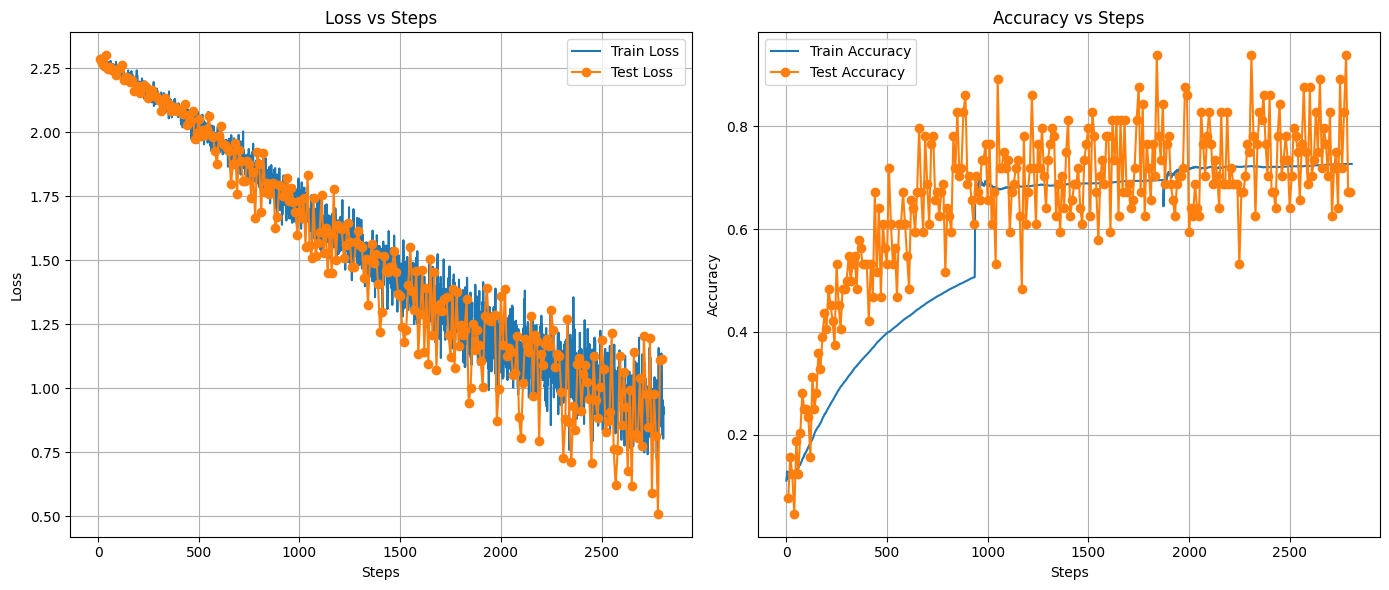

In [ ]:
!pip install opacus
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

from opacus import PrivacyEngine

# define eval
def evaluate_on_random_batch(model, device, test_loader, criterion):
    model.eval()
    with torch.no_grad():
        # sampling a batch
        test_batches = list(test_loader)
        data, target = random.choice(test_batches)
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target).item()
        preds = output.argmax(dim=1)
        correct = preds.eq(target).sum().item()
        accuracy = correct / target.size(0)
    model.train()
    return loss, accuracy

# define model
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        x = x.view(-1, 28*28)  # flatten dim
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def main():
    # check device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # preprocessing
    transform = transforms.Compose([transforms.ToTensor()])

    # load dataset
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    batch_size = 64
    num_workers = 4
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    # init model, loss, optimizer
    model = SimpleNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    # DP params
    epsilon = 5.0
    delta = 1e-5
    max_grad_norm = 1.0
    noise_multiplier = 1.1

    # use PrivacyEngine to add DP noise
    privacy_engine = PrivacyEngine()
    model, optimizer, train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=noise_multiplier,
        max_grad_norm=max_grad_norm,
    )

    # training params
    num_epochs = 3
    eval_steps = 10

    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []
    train_steps = []
    test_steps = []

    global_step = 0

    for epoch in range(num_epochs):
        model.train()
        total_correct = 0
        total_samples = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for batch_idx, (data, target) in enumerate(progress_bar):
            global_step += 1
            data, target = data.to(device), target.to(device)

            # forward pass
            output = model(data)
            loss = criterion(output, target)

            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # compute acc
            preds = output.argmax(dim=1)
            correct = preds.eq(target).sum().item()
            total_correct += correct
            total_samples += target.size(0)
            accuracy = total_correct / total_samples

            # record training stats
            train_losses.append(loss.item())
            train_accuracies.append(accuracy)
            train_steps.append(global_step)

            # update progress bar
            progress_bar.set_postfix(loss=loss.item(), accuracy=accuracy)

            # every eval_steps test on test set
            if global_step % eval_steps == 0:
                test_loss, test_accuracy = evaluate_on_random_batch(model, device, test_loader, criterion)
                test_losses.append(test_loss)
                test_accuracies.append(test_accuracy)
                test_steps.append(global_step)

        # get privacy budget
        epsilon_spent = privacy_engine.get_epsilon(delta)
        print(f"Epoch {epoch+1} completed. (ε = {epsilon_spent:.2f}, δ = {delta})")

    # plot loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

    ax1.plot(train_steps, train_losses, label='Train Loss')
    ax1.plot(test_steps, test_losses, label='Test Loss', marker='o')
    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss vs Steps')
    ax1.legend()
    ax1.grid(True)

    # plot acc
    ax2.plot(train_steps, train_accuracies, label='Train Accuracy')
    ax2.plot(test_steps, test_accuracies, label='Test Accuracy', marker='o')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy vs Steps')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


Now, we will explore the impact of differential privacy on the model's performance. DPSGD combines
differential privacy mechanism and SGD together as an optimizer. We will use DPSGD instead of SGD. Please
make sure you have download DPSGD.py file with the same root of this file.

# **Conclusion**
In this lab, we have learnt:
1. defining tensors;
2. basic operations of tensors;
3. MNIST dataset
4. deep leaning and neural network;
5. DP-SGD in deep learning
From the training results we can know that:
1. the noise from differential privacy (DP-SGD) may slightly reduce the accuracy of model.
2. the size of noise is affected by sensitivity and privacy budget.
3. it is important to balance the privacy and model ultility.